# This notebook contains the EDA of the financial fraud dataset from Kaggle

In [1]:
#%pip install -r ../requirements.txt -q

In [2]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

/Users/angjiayi/code/DSA4263/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [3]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print("Shape:", df.shape)
print(df.head())
print(df.info())


Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv
Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        

In [4]:
# checking the missing values in the data
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
# Check for duplicates
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Check for conditional duplicates
dup_subset = df[df.duplicated(subset=['nameOrig', 'nameDest', 'type'], keep=False)]
print(f"Potential duplicate transactions (same sender, receiver, type): {dup_subset.shape[0]}")

dup_subset = df[df.duplicated(subset=['nameOrig', 'nameDest'], keep=False)]
print(f"Potential duplicate transactions (same sender, receiver): {dup_subset.shape[0]}")


Number of duplicate rows: 0
Potential duplicate transactions (same sender, receiver, type): 0
Potential duplicate transactions (same sender, receiver): 0


Identify accounts appearing both as nameOrig and nameDest

In [6]:
senders = set(df['nameOrig'].unique())
receivers = set(df['nameDest'].unique())


overlap_accounts = senders.intersection(receivers)

print(f"Total unique senders: {len(senders)}")
print(f"Total unique receivers: {len(receivers)}")
print(f"Accounts appearing as both sender and receiver: {len(overlap_accounts)}")



suspicious_df = df[df['nameOrig'].isin(overlap_accounts) | df['nameDest'].isin(overlap_accounts)]

print(suspicious_df.head(10))

Total unique senders: 6353307
Total unique receivers: 2722362
Accounts appearing as both sender and receiver: 1769
      step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
559      1  TRANSFER  100588.80  C1636588948       18913.68            0.00   
571      1   PAYMENT    3316.21  C1626852381           0.00            0.00   
862      1  CASH_OUT  171757.76  C1673916398           0.00            0.00   
1262     1   CASH_IN   35492.20  C1540476618      444567.92       480060.12   
1307     1   CASH_IN   82564.24   C322830747     6739112.35      6821676.59   
1321     1   CASH_IN  170207.14  C1816468636     8335475.31      8505682.45   
3534     2     DEBIT    4390.62   C571251299       69336.00        64945.38   
5699     6     DEBIT    7821.80   C486965279       19353.00        11531.20   
7091     6   CASH_IN   88549.90  C2141744605     4320892.68      4409442.58   
8572     7   CASH_IN   35884.67  C1359875538     2335651.45      2371536.12   

         nameDe

In [7]:
# How many transactions involve overlapping accounts
total_txn = df.shape[0]
overlap_txn = suspicious_df.shape[0]
print(f"Percentage of transactions involving dual-role accounts: {(overlap_txn / total_txn) * 100:.2f}%")

# Fraud rate among overlapping accounts
fraud_overlap = suspicious_df['isFraud'].sum()
fraud_rate_overlap = fraud_overlap / suspicious_df.shape[0]
overall_fraud_rate = df['isFraud'].mean()

print(f"Fraud rate (overlap accounts): {fraud_rate_overlap:.4f}")
print(f"Overall fraud rate (entire dataset): {overall_fraud_rate:.4f}")

Percentage of transactions involving dual-role accounts: 0.24%
Fraud rate (overlap accounts): 0.0012
Overall fraud rate (entire dataset): 0.0013


## new EDA

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

1. Transaction type insights

Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud rate by type:
type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


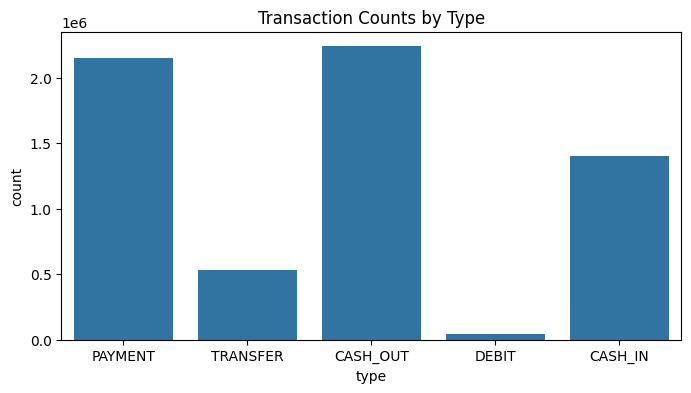

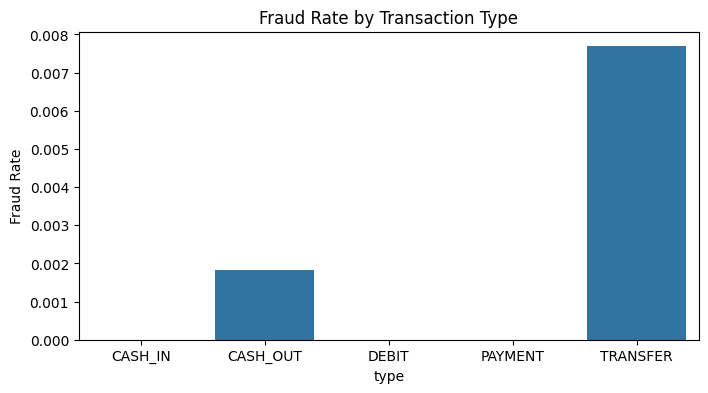

In [9]:

print("Transaction type distribution:")
print(df['type'].value_counts())
print("\nFraud rate by type:")
print(df.groupby('type')['isFraud'].mean())

plt.figure(figsize=(8,4))
sns.countplot(x='type', data=df)
plt.title("Transaction Counts by Type")
plt.show()

plt.figure(figsize=(8,4))
fraud_rate_by_type = df.groupby('type')['isFraud'].mean()
sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

2. Amount analysis

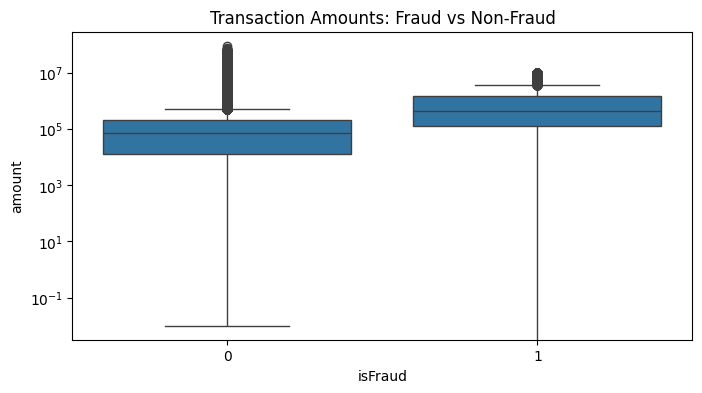


Amount summary (fraud vs non-fraud):
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')  # amounts vary a lot
plt.title("Transaction Amounts: Fraud vs Non-Fraud")
plt.show()

print("\nAmount summary (fraud vs non-fraud):")
print(df.groupby('isFraud')['amount'].describe())

3. Temporal patterns (step)

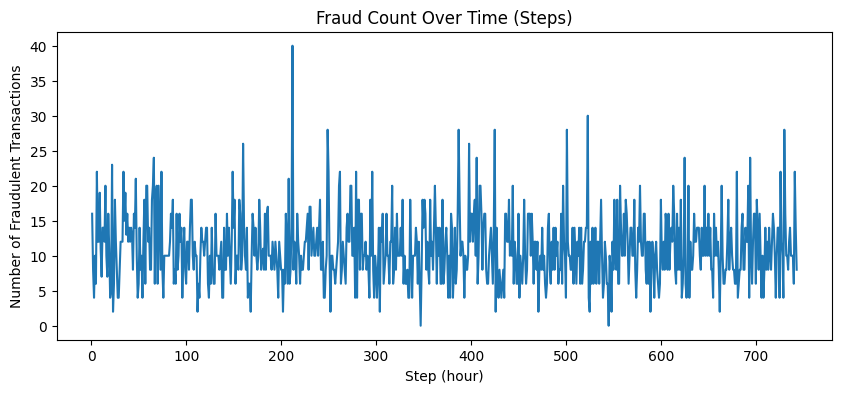

In [11]:
plt.figure(figsize=(10,4))
df.groupby('step')['isFraud'].sum().plot()
plt.title("Fraud Count Over Time (Steps)")
plt.xlabel("Step (hour)")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

4. Sender / Receiver behavior


Transactions per sender (summary):
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64

Top 10 senders by total amount:
nameOrig
C1715283297    92445516.64
C2127282686    73823490.36
C2044643633    71172480.42
C1425667947    69886731.30
C1584456031    69337316.27
C811810230     67500761.29
C420748282     66761272.21
C1139847449    64234448.19
C300140823     63847992.58
C372535854     63294839.63
Name: amount, dtype: float64


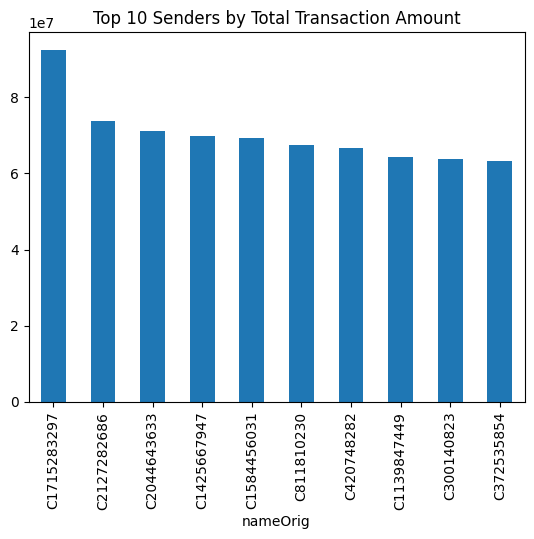

In [12]:
print("\nTransactions per sender (summary):")
print(df['nameOrig'].value_counts().describe())

top_senders = df.groupby('nameOrig')['amount'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 senders by total amount:")
print(top_senders)

top_senders.plot(kind='bar')
plt.title("Top 10 Senders by Total Transaction Amount")
plt.show()

5. Fraud vs non-fraud ratio

In [13]:
fraud_ratio = df['isFraud'].value_counts(normalize=True)
print("\nFraud vs Non-Fraud ratio:")
print(fraud_ratio)


Fraud vs Non-Fraud ratio:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [14]:
# According to Kaggle dataset documentation, these features should be excluded for fraud analysis
cols_to_drop = ['nameOrig', 'nameDest', 'newbalanceOrig', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest']
df_encode = df.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)
print("New shape:", df_encode.shape)
# Show all remaining columns
print(df_encode.columns)


Dropped columns: ['nameOrig', 'nameDest', 'newbalanceOrig', 'oldbalanceOrg', 'newbalanceDest', 'oldbalanceDest']
New shape: (6362620, 5)
Index(['step', 'type', 'amount', 'isFraud', 'isFlaggedFraud'], dtype='object')


In [15]:
# Encode 'type' column
df_encode['type'] = df_encode['type'].astype('category').cat.codes

# Correlation:

**Correlation** measures the linear relationship between two variables:
- Range: -1 to +1
- +1 = perfect positive correlation
- 0 = no linear relationship  
- -1 = perfect negative correlation
- Only considers **pairwise** relationships (low pairwise correlations == each pair look independent)

In [16]:
corr = df_encode.corr(numeric_only=True)

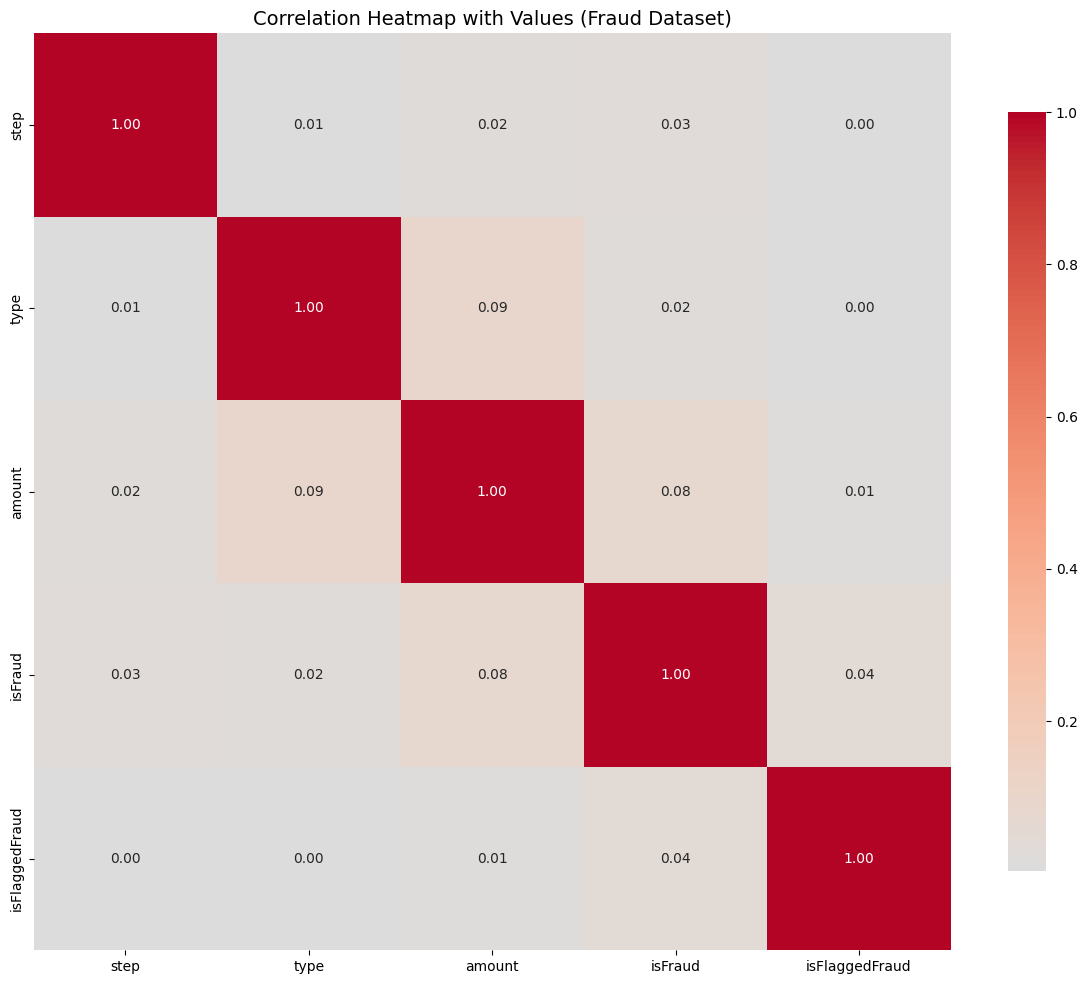

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap with Values (Fraud Dataset)", fontsize=14)
plt.tight_layout()
plt.show()

# Collinearity:

**Collinearity** (Multicollinearity) refers to when predictor variables are linearly dependent:
- Measured using **VIF (Variance Inflation Factor)**
- VIF > 5: Moderate collinearity
- VIF > 10: High collinearity (problematic for modeling)
- Considers **multiple variables** simultaneously
- Can exist even when pairwise correlations are low!

In [18]:
# Calculate VIF (Variance Inflation Factor) for Collinearity Detection
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Select numeric features for VIF calculation (excluding target variable 'isFraud')
numeric_features = df_encode.select_dtypes(include=[np.number]).columns.tolist()
if 'isFraud' in numeric_features:
    numeric_features.remove('isFraud')

# Create feature matrix for VIF calculation
X = df_encode[numeric_features].dropna()

# Calculate VIF for each feature
vif_data = []
for i in range(X.shape[1]):
    vif_value = variance_inflation_factor(X.values, i)
    vif_data.append({'Feature': X.columns[i], 'VIF': vif_value})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) - Collinearity Detection:")
print("="*50)
for _, row in vif_df.iterrows():
    status = ""
    if row['VIF'] > 10:
        status = "HIGH COLLINEARITY"
    elif row['VIF'] > 5:
        status = "MODERATE COLLINEARITY"
    else:
        status = "LOW COLLINEARITY"

    print(f"{row['Feature']:<15}: {row['VIF']:>8.2f} {status}")

Variance Inflation Factor (VIF) - Collinearity Detection:
type           :     1.90 LOW COLLINEARITY
step           :     1.88 LOW COLLINEARITY
amount         :     1.09 LOW COLLINEARITY
isFlaggedFraud :     1.00 LOW COLLINEARITY


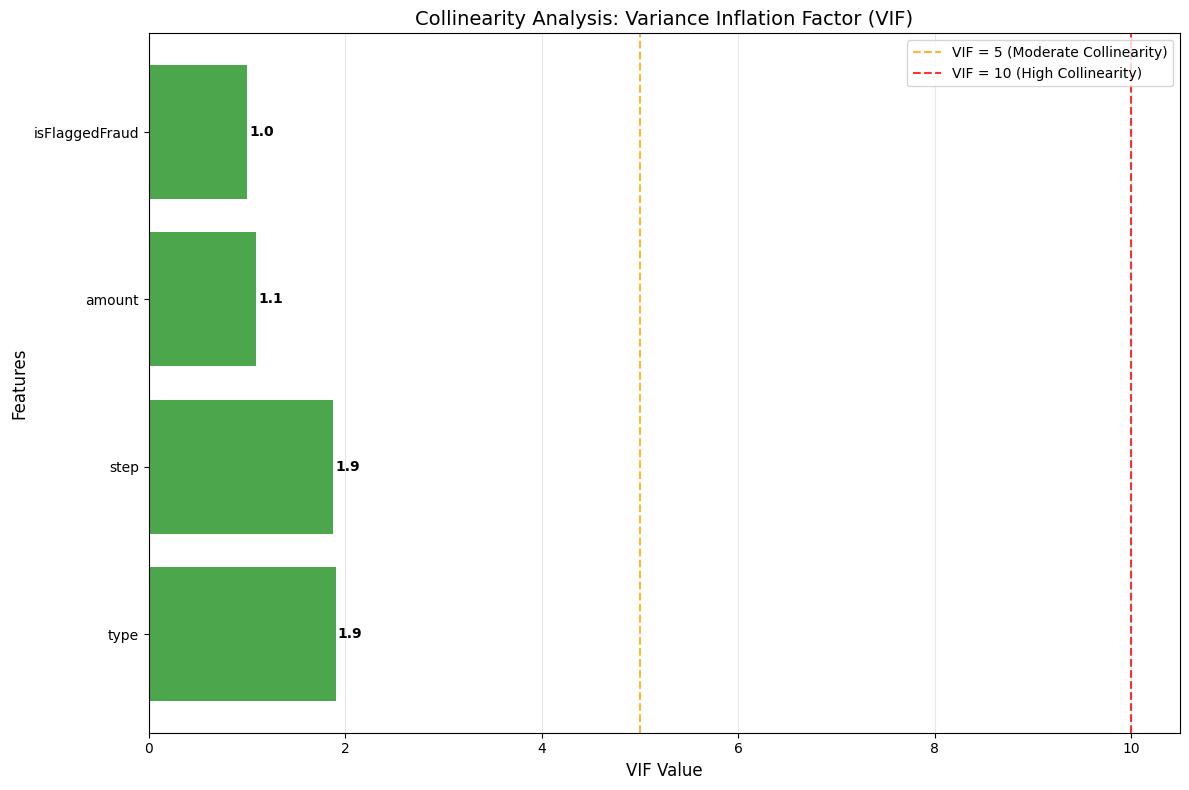


VIF Interpretation:
VIF < 5:  Low collinearity (good for modeling)
5 ≤ VIF < 10: Moderate collinearity (monitor)
VIF ≥ 10: High collinearity (consider removing)

Collinearity shows how well each variable can be predicted
from ALL other variables combined (multivariate relationship)


In [19]:
# Create VIF visualization for Collinearity
plt.figure(figsize=(12, 8))

# VIF Bar Chart
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = plt.barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)

# Add reference lines
plt.axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate Collinearity)')
plt.axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High Collinearity)')

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    plt.text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{vif_val:.1f}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Collinearity Analysis: Variance Inflation Factor (VIF)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nVIF Interpretation:")
print("="*40)
print("VIF < 5:  Low collinearity (good for modeling)")
print("5 ≤ VIF < 10: Moderate collinearity (monitor)")
print("VIF ≥ 10: High collinearity (consider removing)")
print("\nCollinearity shows how well each variable can be predicted")
print("from ALL other variables combined (multivariate relationship)")

# Collinearity and Correlation Plot

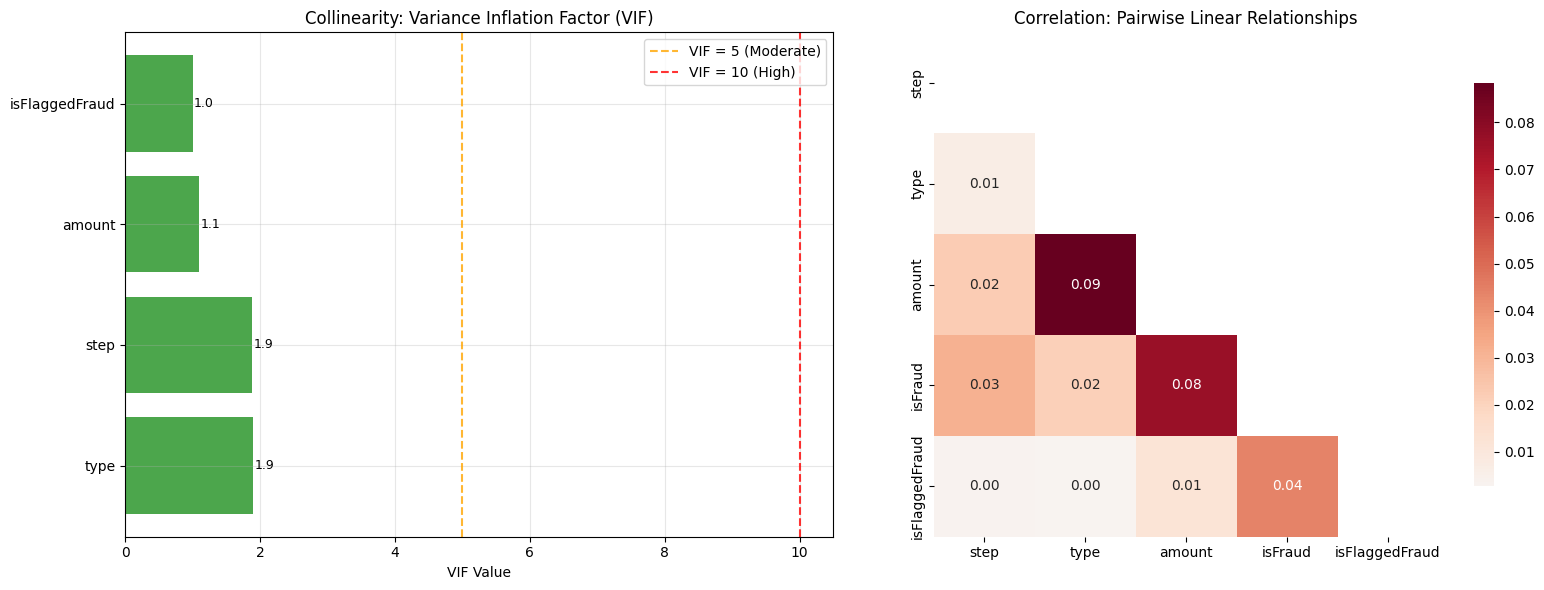


Comparison Summary:
Left plot (VIF): Shows multivariate collinearity - how well each variable
                 can be predicted from ALL other variables combined
Right plot (Correlation): Shows pairwise relationships - how each variable
                         relates to just ONE other variable at a time


In [20]:
# Create comparison plots: Correlation vs Collinearity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: VIF Bar Chart (Collinearity)
vif_colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_df['VIF']]
bars = axes[0].barh(vif_df['Feature'], vif_df['VIF'], color=vif_colors, alpha=0.7)
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5 (Moderate)')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10 (High)')
axes[0].set_xlabel('VIF Value')
axes[0].set_title('Collinearity: Variance Inflation Factor (VIF)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add VIF values on bars
for i, (bar, vif_val) in enumerate(zip(bars, vif_df['VIF'])):
    axes[0].text(vif_val + max(vif_df['VIF']) * 0.01, bar.get_y() + bar.get_height()/2,
                f'{vif_val:.1f}', va='center', fontsize=9)

# Plot 2: Correlation Heatmap (clean version)
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, annot=True, cmap='RdBu_r', center=0,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8}, fmt='.2f')
axes[1].set_title('Correlation: Pairwise Linear Relationships')

plt.tight_layout()
plt.show()

print("\nComparison Summary:")
print("="*50)
print("Left plot (VIF): Shows multivariate collinearity - how well each variable")
print("                 can be predicted from ALL other variables combined")
print("Right plot (Correlation): Shows pairwise relationships - how each variable")
print("                         relates to just ONE other variable at a time")

# Feature Engineering

In [21]:
# Create a derived 'day' variable
df['day'] = (df['step'] // 24).astype(int)

# Count number of transactions per user per day
txn_freq_per_day = (
    df.groupby(['nameOrig', 'day'])
    .size()
    .reset_index(name='txn_count_day')
)


df = df.merge(txn_freq_per_day, on=['nameOrig', 'day'], how='left')
df.rename(columns={'txn_count_day': 'transactionFrequency_day'}, inplace=True)


df[['nameOrig', 'day', 'transactionFrequency_day']].head(10)

,nameOrig,day,transactionFrequency_day
0,C1231006815,0,1
1,C1666544295,0,1
2,C1305486145,0,1
3,C840083671,0,1
4,C2048537720,0,1
5,C90045638,0,1
6,C154988899,0,1
7,C1912850431,0,1
8,C1265012928,0,1
9,C712410124,0,1


### Transaction velocity
transactionFrequency (per user):
Number of transactions per time step or per day.

In [22]:
txn_freq_per_step = (
    df.groupby(['nameOrig', 'step'])
    .size()
    .reset_index(name='txn_count_step')
)

df = df.merge(txn_freq_per_step, on=['nameOrig', 'step'], how='left')

df.rename(columns={'txn_count_step': 'transactionFrequency'}, inplace=True)


print(df[['nameOrig', 'step', 'transactionFrequency']].head(10))

freq_stats = df.groupby('isFraud')['transactionFrequency'].describe()
print(freq_stats)


      nameOrig  step  transactionFrequency
0  C1231006815     1                     1
1  C1666544295     1                     1
2  C1305486145     1                     1
3   C840083671     1                     1
4  C2048537720     1                     1
5    C90045638     1                     1
6   C154988899     1                     1
7  C1912850431     1                     1
8  C1265012928     1                     1
9   C712410124     1                     1
             count      mean       std  min  25%  50%  75%  max
isFraud                                                        
0        6354407.0  1.000015  0.003846  1.0  1.0  1.0  1.0  2.0
1           8213.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0


In [23]:
avg_amt_per_step = (
    df.groupby(['nameOrig', 'step'])['amount']
    .mean()
    .reset_index(name='avgAmountPerStep')
)

df = df.merge(avg_amt_per_step, on=['nameOrig', 'step'], how='left')

avg_stats = df.groupby('isFraud')['avgAmountPerStep'].describe()
print(avg_stats)



             count          mean           std   min        25%        50%  \
isFraud                                                                      
0        6354407.0  1.781970e+05  5.962361e+05  0.01   13368.65   74685.53   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.33  441423.44   

                75%          max  
isFraud                           
0         208364.55  92445516.64  
1        1517771.48  10000000.00  


In [24]:
sender_connections = (
    df.groupby('nameOrig')['nameDest']
    .nunique()
    .reset_index(name='distinctNameDest_perSender')
)

# 2️⃣ Number of distinct senders per receiver
receiver_connections = (
    df.groupby('nameDest')['nameOrig']
    .nunique()
    .reset_index(name='distinctNameOrig_perReceiver')
)

# 3️⃣ Merge back into the main DataFrame
df = df.merge(sender_connections, on='nameOrig', how='left')
df = df.merge(receiver_connections, on='nameDest', how='left')

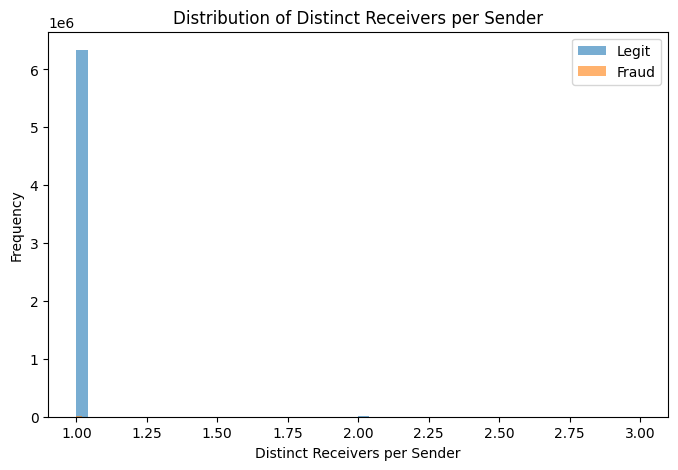

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df[df['isFraud']==0]['distinctNameDest_perSender'], bins=50, alpha=0.6, label='Legit')
plt.hist(df[df['isFraud']==1]['distinctNameDest_perSender'], bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.title('Distribution of Distinct Receivers per Sender')
plt.xlabel('Distinct Receivers per Sender')
plt.ylabel('Frequency')
plt.show()

### Time Since Last Transaction
Captures time gap between consecutive transactions per user. Sudden bursts (very small gaps) can indicate bot or collusion behavior.

In [26]:
# Sort by user and time to get transactions in chronological order
df_sorted = df.sort_values(['nameOrig', 'step'])

# Calculate time difference from previous transaction for each user
df_sorted['timeSinceLastTransaction'] = df_sorted.groupby('nameOrig')['step'].diff()

# For the first transaction of each user, set to NaN (or you could set to step value)
# Fill NaN with the step value (time since beginning) or keep as NaN
df_sorted['timeSinceLastTransaction'] = df_sorted['timeSinceLastTransaction'].fillna(df_sorted['step'])

# Merge back to original dataframe
df = df_sorted.copy()

# Show sample
print("Sample of timeSinceLastTransaction:")
print(df[['nameOrig', 'step', 'timeSinceLastTransaction']].head(20))

# Compare fraud vs non-fraud
print("\nTime Since Last Transaction - Fraud vs Non-Fraud:")
print(df.groupby('isFraud')['timeSinceLastTransaction'].describe())

Sample of timeSinceLastTransaction:
            nameOrig  step  timeSinceLastTransaction
3196942  C1000000639   249                     249.0
2798983  C1000001337   217                     217.0
1013585  C1000001725    46                      46.0
2980283  C1000002591   231                     231.0
1920204  C1000003372   167                     167.0
3374567  C1000003615   254                     254.0
4548211  C1000004053   327                     327.0
847860   C1000004530    41                      41.0
2825292  C1000005353   226                     226.0
2202461  C1000005555   185                     185.0
5502195  C1000005749   380                     380.0
3754850  C1000005789   279                     279.0
4232025  C1000006646   306                     306.0
4060854  C1000006873   300                     300.0
3358087  C1000008111   254                     254.0
4275204  C1000008236   307                     307.0
3789087  C1000008393   280                     280.0
492522   C

/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_53408/859336931.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['isFraud']==0]['timeSinceLastTransaction'].dropna(),


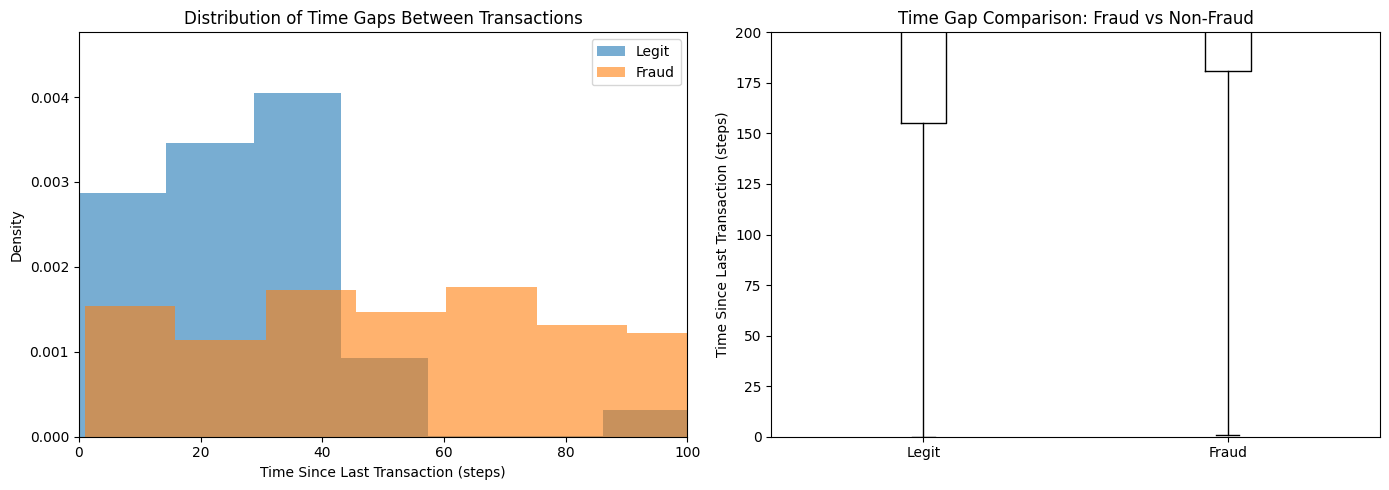


Transactions with burst behavior (<= 5 steps):
Total: 5878
Fraud rate: 0.0075
Overall fraud rate: 0.0013


In [27]:
# Visualize distribution of time gaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram comparison
axes[0].hist(df[df['isFraud']==0]['timeSinceLastTransaction'].dropna(), 
             bins=50, alpha=0.6, label='Legit', density=True)
axes[0].hist(df[df['isFraud']==1]['timeSinceLastTransaction'].dropna(), 
             bins=50, alpha=0.6, label='Fraud', density=True)
axes[0].set_xlabel('Time Since Last Transaction (steps)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Time Gaps Between Transactions')
axes[0].legend()
axes[0].set_xlim(0, 100)  # Focus on shorter time gaps

# Plot 2: Box plot for comparison
axes[1].boxplot([df[df['isFraud']==0]['timeSinceLastTransaction'].dropna(),
                 df[df['isFraud']==1]['timeSinceLastTransaction'].dropna()],
                labels=['Legit', 'Fraud'])
axes[1].set_ylabel('Time Since Last Transaction (steps)')
axes[1].set_title('Time Gap Comparison: Fraud vs Non-Fraud')
axes[1].set_ylim(0, 200)  # Focus on reasonable range

plt.tight_layout()
plt.show()

# Identify potential burst behavior (very short time gaps)
burst_threshold = 5  # transactions within 5 steps
burst_txns = df[df['timeSinceLastTransaction'] <= burst_threshold]
print(f"\nTransactions with burst behavior (<= {burst_threshold} steps):")
print(f"Total: {burst_txns.shape[0]}")
print(f"Fraud rate: {burst_txns['isFraud'].mean():.4f}")
print(f"Overall fraud rate: {df['isFraud'].mean():.4f}")

### Self-Transfer Detection
Flag transactions where sender = receiver (nameOrig == nameDest). Self-transfers are often used for fraud testing or money laundering.

In [28]:
# Create binary flag for self-transfers
df['sameUserTransaction'] = (df['nameOrig'] == df['nameDest']).astype(int)

# Analyze self-transfer patterns
print("Self-Transfer Analysis:")
print("="*50)
print(f"Total self-transfers: {df['sameUserTransaction'].sum()}")
print(f"Percentage of all transactions: {(df['sameUserTransaction'].mean() * 100):.4f}%")

# Fraud rate comparison
print("\nFraud Rate Analysis:")
print(f"Fraud rate in self-transfers: {df[df['sameUserTransaction']==1]['isFraud'].mean():.4f}")
print(f"Fraud rate in normal transfers: {df[df['sameUserTransaction']==0]['isFraud'].mean():.4f}")
print(f"Overall fraud rate: {df['isFraud'].mean():.4f}")

# Cross-tabulation
print("\nCross-tabulation (Self-Transfer vs Fraud):")
cross_tab = pd.crosstab(df['sameUserTransaction'], df['isFraud'], 
                         normalize='index', margins=True)
print(cross_tab)

# Show sample self-transfers
print("\nSample of Self-Transfer Transactions:")
self_transfers = df[df['sameUserTransaction']==1][['nameOrig', 'nameDest', 'amount', 'type', 'isFraud']].head(10)
print(self_transfers)

Self-Transfer Analysis:
Total self-transfers: 0
Percentage of all transactions: 0.0000%

Fraud Rate Analysis:
Fraud rate in self-transfers: nan
Fraud rate in normal transfers: 0.0013
Overall fraud rate: 0.0013

Cross-tabulation (Self-Transfer vs Fraud):
isFraud                     0         1
sameUserTransaction                    
0                    0.998709  0.001291
All                  0.998709  0.001291

Sample of Self-Transfer Transactions:
Empty DataFrame
Columns: [nameOrig, nameDest, amount, type, isFraud]
Index: []


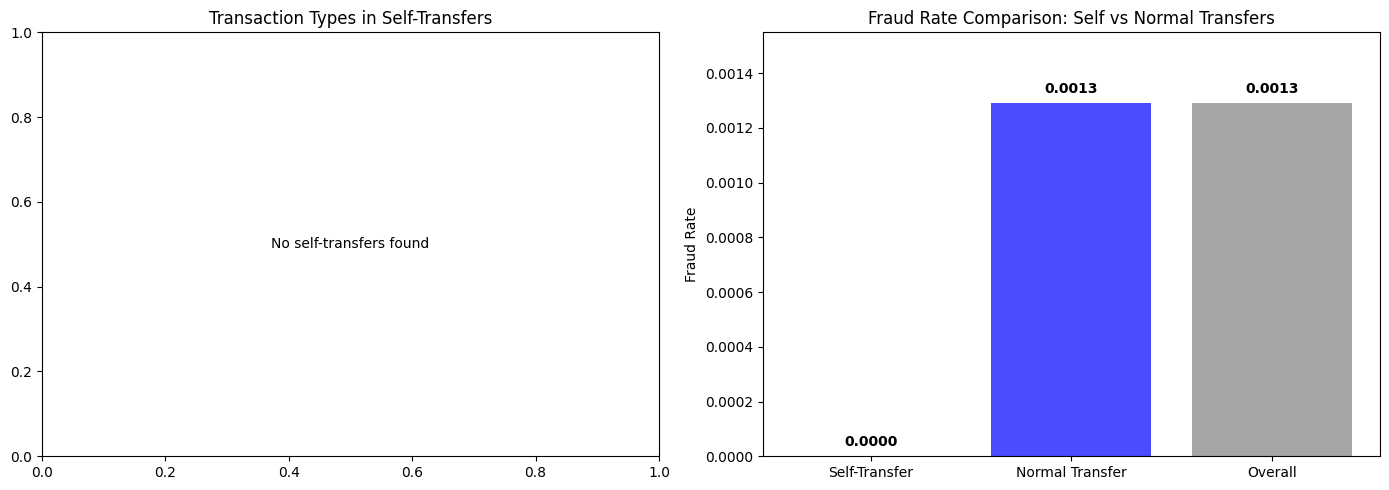

In [29]:
# Visualize self-transfer analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of transaction types for self-transfers
if df['sameUserTransaction'].sum() > 0:
    self_transfer_types = df[df['sameUserTransaction']==1]['type'].value_counts()
    axes[0].bar(self_transfer_types.index, self_transfer_types.values, alpha=0.7, color='coral')
    axes[0].set_xlabel('Transaction Type')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Transaction Types in Self-Transfers')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No self-transfers found', ha='center', va='center')
    axes[0].set_title('Transaction Types in Self-Transfers')

# Plot 2: Fraud rate comparison
categories = ['Self-Transfer', 'Normal Transfer', 'Overall']
fraud_rates = [
    df[df['sameUserTransaction']==1]['isFraud'].mean() if df['sameUserTransaction'].sum() > 0 else 0,
    df[df['sameUserTransaction']==0]['isFraud'].mean(),
    df['isFraud'].mean()
]
colors = ['red', 'blue', 'gray']
axes[1].bar(categories, fraud_rates, alpha=0.7, color=colors)
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate Comparison: Self vs Normal Transfers')
axes[1].set_ylim(0, max(fraud_rates) * 1.2 if max(fraud_rates) > 0 else 1)

# Add value labels on bars
for i, (cat, rate) in enumerate(zip(categories, fraud_rates)):
    axes[1].text(i, rate + max(fraud_rates)*0.02, f'{rate:.4f}', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Risk assessment
if df['sameUserTransaction'].sum() > 0:
    risk_ratio = (df[df['sameUserTransaction']==1]['isFraud'].mean() / 
                  df[df['sameUserTransaction']==0]['isFraud'].mean())
    print(f"\n🔍 Risk Assessment:")
    print(f"Self-transfers are {risk_ratio:.2f}x more likely to be fraudulent than normal transfers")